In [17]:
# %pip install deltalake matplotlib seaborn xgboost scikit-learn
# %pip install mlflow

In [2]:
import pandas as pd
from deltalake import DeltaTable
import matplotlib.pyplot as plt
import seaborn as sns

dt = DeltaTable("../data/gold/time_series_features")
df = dt.to_pandas()

df_sort = df.sort_values(by = ["client_id", "txn_month"])

print(f"Loaded {len(df)} monthly records.")
display(df.head())

Loaded 126262 monthly records.


,client_id,txn_month,current_month_spend,spend_1_month_ago,spend_2_months_ago,spend_3_months_ago,avg_spend_last_3_months
0,0,2010-01,436.0,NaN,NaN,NaN,NaN
1,0,2010-02,470.0,436.0,NaN,NaN,436.00
2,0,2010-03,803.0,470.0,436.0,NaN,453.00
3,0,2010-04,235.0,803.0,470.0,436.0,569.67
4,0,2010-05,290.0,235.0,803.0,470.0,502.67


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126262 entries, 0 to 126261
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   client_id                126262 non-null  object 
 1   txn_month                126262 non-null  object 
 2   current_month_spend      126262 non-null  float64
 3   spend_1_month_ago        125043 non-null  float64
 4   spend_2_months_ago       123824 non-null  float64
 5   spend_3_months_ago       122606 non-null  float64
 6   avg_spend_last_3_months  125043 non-null  float64
dtypes: float64(5), object(2)
memory usage: 6.7+ MB


In [4]:
df.fillna(0, inplace=True)

Monthly spending trend of a user

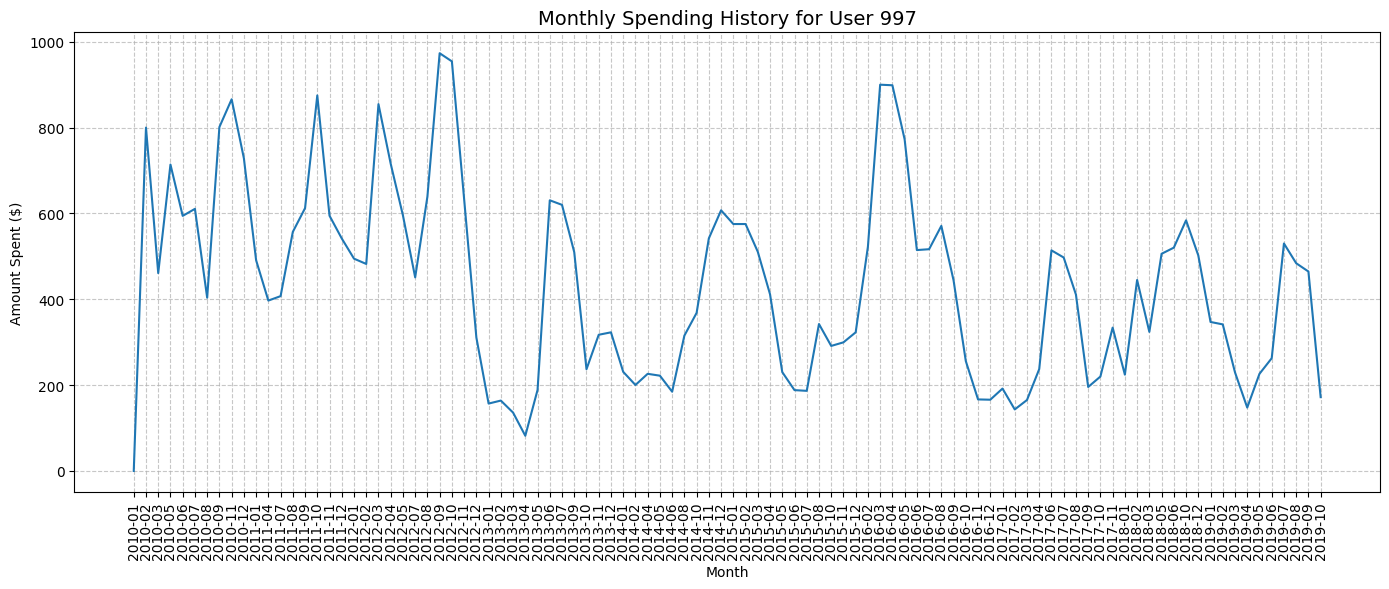

In [5]:
df = df.sort_values(by=['client_id', 'txn_month'])
# Pick the first user in the dataset
sample_user = df['client_id'].iloc[-1]
user_data = df[df['client_id'] == sample_user]

plt.figure(figsize=(14, 6))
sns.lineplot(data=user_data, x='txn_month', y='avg_spend_last_3_months', markers='o')

plt.title(f"Monthly Spending History for User {sample_user}", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Amount Spent ($)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Since the actual user current month spending shows high volatility it wont be a good feature to predict and I'm trying to see how the avg spend across three months(rolling 3 months avg spend) impact

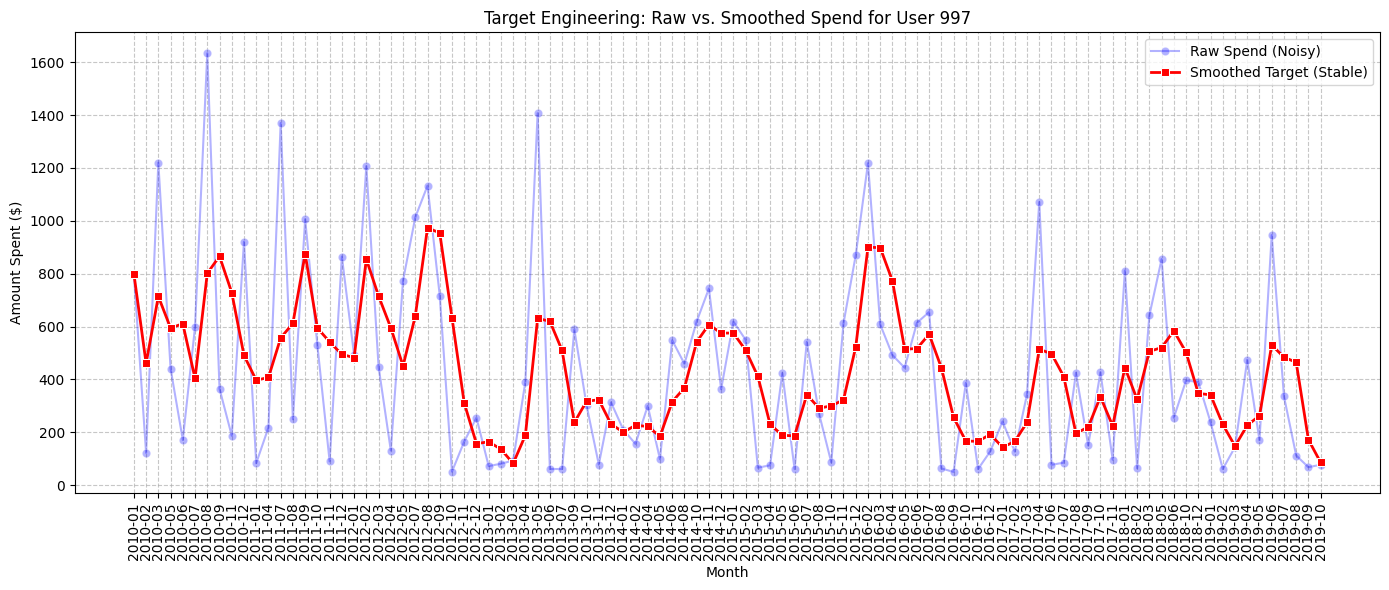

In [6]:
# 1. Create a "Smoothed" Target (3-Month Rolling Average of their actual spend)
# group by user, and take the rolling mean of the current and previous 2 months.
df['smoothed_target_spend'] = df.groupby('client_id')['current_month_spend'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().round(2)
)

sample_user = df['client_id'].iloc[-1]
user_data = df[df['client_id'] == sample_user]

plt.figure(figsize=(14, 6))
sns.lineplot(data=user_data, x='txn_month', y='current_month_spend', marker='o', color='blue', alpha=0.3, label='Raw Spend (Noisy)')
sns.lineplot(data=user_data, x='txn_month', y='smoothed_target_spend', marker='s', color='red', linewidth=2, label='Smoothed Target (Stable)')

plt.title(f"Target Engineering: Raw vs. Smoothed Spend for User {sample_user}")
plt.xlabel("Month")
plt.ylabel("Amount Spent ($)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

It looks better than waht I saw earlier, so Im going to use this new feature as my target variable

### Define Features and Base line model

In [8]:
# Sort perfectly by time just to be absolutely safe
df = df.sort_values(by=['client_id', 'txn_month'])

# Grab the last 2 months for EVERY user to be our Test set
test_df = df.groupby('client_id').tail(2)

# Everything else becomes the Training set
train_df = df.drop(test_df.index)

print(f"Training Rows: {len(train_df)}")
print(f"Testing Rows (Last 2 months): {len(test_df)}")

Training Rows: 123824
Testing Rows (Last 2 months): 2438


In [9]:
from sklearn.metrics import mean_absolute_error

# Define our X (Features) and y (Target)
features = ['spend_1_month_ago', 'spend_2_months_ago', 'spend_3_months_ago', 'avg_spend_last_3_months']
target = 'current_month_spend'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# THE BASELINE: Predict that this month is exactly equal to 1 month ago
baseline_predictions = X_test['spend_1_month_ago']

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
print(f"Baseline (Naive) MAE: ${baseline_mae:.2f}")

Baseline (Naive) MAE: $327.83


In [10]:
from xgboost import XGBRegressor

# Initialize the model
print("Training XGBoost Model...")
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=4, 
    random_state=42
)

# Train the model on the past data
xgb_model.fit(X_train, y_train)

# Make predictions on the unseen future data
xgb_predictions = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
print(f"XGBoost MAE: ${xgb_mae:.2f}")

# Did we win?
if xgb_mae < baseline_mae:
    print(f"✅ SUCCESS! XGBoost beat the baseline by ${baseline_mae - xgb_mae:.2f} per month.")
else:
    print(f"❌ FAIL. The model is worse than just guessing last month's spend.")

Training XGBoost Model...
XGBoost MAE: $249.89
✅ SUCCESS! XGBoost beat the baseline by $77.95 per month.


### Try to predict the avg_spend_last_3_months



In [11]:
test_df = df.groupby('client_id').tail(2)

# Everything else becomes the Training set
train_df = df.drop(test_df.index)

features = ['current_month_spend', 'spend_1_month_ago', 'spend_2_months_ago']
target = 'smoothed_target_spend'

X_train, X_test = train_df[features], test_df[features]
y_train, y_test = train_df[target], test_df[target]

# THE BASELINE: Predict that this month is exactly equal to 1 month ago
baseline_predictions = X_test['spend_1_month_ago']

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
print(f"Baseline (Naive) MAE: ${baseline_mae:.2f}")

Baseline (Naive) MAE: $193.37


In [12]:
from xgboost import XGBRegressor

# Initialize the model
print("Training XGBoost Model...")
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=4, 
    random_state=42
)

# Train the model on the past data
xgb_model.fit(X_train, y_train)

# Make predictions on the unseen future data
xgb_predictions = xgb_model.predict(X_test)
# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

train_predictions = xgb_model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_predictions)

print(f"Training MAE: ${train_mae:.2f}")
print(f"XGBoost MAE: ${xgb_mae:.2f}")

# Did we win?
if xgb_mae < baseline_mae:
    print(f"✅ SUCCESS! XGBoost beat the baseline by ${baseline_mae - xgb_mae:.2f} per month.")
else:
    print(f"❌ FAIL. The model is worse than just guessing last month's spend.")

Training XGBoost Model...
Training MAE: $11.95
XGBoost MAE: $11.60
✅ SUCCESS! XGBoost beat the baseline by $181.77 per month.


In [13]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, xgb_predictions)
print(f"XGBoost MAPE: {mape:.2%}")

XGBoost MAPE: 2.43%


In [18]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import time

print("Starting Hyperparameter Tuning (This might take a minute)...")
start_time = time.time()

# 1. Define the parameter grid we want to test
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# 2. Use TimeSeriesSplit to respect the chronological order of data
tscv = TimeSeriesSplit(n_splits=3)

# 3. Set up the Grid Search
base_xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=base_xgb, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, # Use all CPU cores
    verbose=1
)

# 4. Run the search on the Training Data
grid_search.fit(X_train, y_train)

print(f"\n--- Tuning Complete in {round(time.time() - start_time, 1)} seconds ---")
print("Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

# 5. Test the optimized model
optimized_xgb = grid_search.best_estimator_
optimized_predictions = optimized_xgb.predict(X_test)
optimized_mae = mean_absolute_error(y_test, optimized_predictions)

print(f"\nOriginal XGBoost MAE:  ${xgb_mae:.2f}")
print(f"Optimized XGBoost MAE: ${optimized_mae:.2f}")

Starting Hyperparameter Tuning (This might take a minute)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Tuning Complete in 13.2 seconds ---
Best Parameters Found:
 - learning_rate: 0.1
 - max_depth: 6
 - n_estimators: 200

Original XGBoost MAE:  $11.60
Optimized XGBoost MAE: $8.08


In [14]:
from xgboost import XGBRegressor

# Initialize the model
print("Training XGBoost Model...")
xgb_model = XGBRegressor(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
)

# Train the model on the past data
xgb_model.fit(X_train, y_train)

# Make predictions on the unseen future data
xgb_predictions = xgb_model.predict(X_test)
# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

train_predictions = xgb_model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_predictions)

print(f"Training MAE: ${train_mae:.2f}")
print(f"XGBoost MAE: ${xgb_mae:.2f}")


Training XGBoost Model...
Training MAE: $7.80
XGBoost MAE: $8.08


In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("../models/time_series", exist_ok=True)

# Save the model using XGBoost's native JSON format
model_path = "../models/time_series/xgb_spend_forecaster_v1.json"
xgb_model.save_model(model_path)

print(f"Model successfully saved to: {model_path}")

In [20]:
import mlflow
import mlflow.xgboost

# 1. Connect to Docker MLflow server
mlflow.set_tracking_uri("http://localhost:5001")

mlflow.set_experiment("User_Spend_Forecasting")

print("Uploading model to MLflow...")

# 3. Start a run and log the model
with mlflow.start_run() as run:
    
    # Log final metrics
    mlflow.log_metric("Test_MAE", xgb_mae)
    mlflow.log_metric("Train_MAE", train_mae)
    
    # Log the physical model and Register it
    mlflow.xgboost.log_model(
        xgb_model=xgb_model,
        name="forecasting_model",
        registered_model_name="Smart_Portfolio_Spend_Forecaster" # API name
    )
    
    print(f"Model successfully registered! Run ID: {run.info.run_id}")

2026/04/13 15:42:19 INFO mlflow.tracking.fluent: Experiment with name 'User_Spend_Forecasting' does not exist. Creating a new experiment.


Uploading model to MLflow...


2026/04/13 15:42:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'Smart_Portfolio_Spend_Forecaster'.
2026/04/13 15:42:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Smart_Portfolio_Spend_Forecaster, version 1
Created version '1' of model 'Smart_Portfolio_Spend_Forecaster'.


Model successfully registered! Run ID: 78cf2cecdc3e4ce2ad5270dc0a9cddf4
🏃 View run caring-kit-322 at: http://localhost:5001/#/experiments/2/runs/78cf2cecdc3e4ce2ad5270dc0a9cddf4
🧪 View experiment at: http://localhost:5001/#/experiments/2
